In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi
from scipy.optimize import minimize
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D


#definimos las constantes y vectores del problema

masa = 100
Area = 0.05
rho = 1.225
Cd = 0.3
g = 9.81
latitud = np.radians(45)
omega = 7.2921e-5
retardo = 10
vector_omega = [0,omega*np.cos(latitud),omega*np.sin(latitud)]
tolerancia_colicion = 10.0


In [3]:
# a- Definimos las funciones a usar, partiendo por la funcion que describe el movimiento de los misiles

def modelo_misiles(t, estado_actual):
    posicion = estado_actual[0:3]
    velocidad = estado_actual[3:6]
    rapidez = np.linalg.norm(velocidad)
    aceleracion_gravedad = [0,0,-g]
    aceleracion_roce = (-0.5*rho*Cd*Area*rapidez*velocidad)/masa
    aceleracion_coriolis = -2*np.cross(vector_omega, velocidad)
    aceleracion_total = aceleracion_gravedad + aceleracion_roce + aceleracion_coriolis
    return np.concatenate((velocidad, aceleracion_total))

def impacto_suelo(t, estado):
    return estado[2] 
impacto_suelo.terminal = True  
impacto_suelo.direction = -1


In [4]:
#DEFINIMOS LA FUNCION PARA CALCULAR LA TRAYECTORIA DEL MISIL OBJETIVO DADO UN ANGULO DE LANZAMIENTO

def calcular_misil_objetivo():
    theta_1 = np.radians(45)
    psi_1 = np.radians(30)
    vel_1_0 = 500
    estado_inicial_obj = [0,0,0,vel_1_0*np.cos(theta_1)*np.cos(psi_1), vel_1_0*np.cos(theta_1)*np.sin(psi_1), vel_1_0*np.sin(theta_1)]
    tiempo_eval = np.linspace(0,200,500)
    solucion_objetivo = spi.solve_ivp(modelo_misiles, t_span=(0,200), y0=estado_inicial_obj, t_eval=tiempo_eval, method='RK45',dense_output=True,events=impacto_suelo)
    return solucion_objetivo 
    

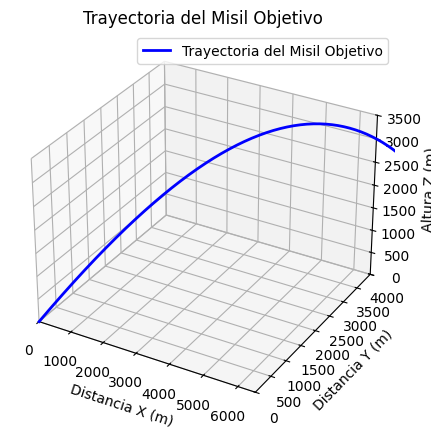

In [5]:
# b- SIMULAMOS NUMERICAMENTE Y LA GRAFICAMOS LA TRAYECORIA DEL MISIL OBJETIVO

simulacion_objetivo = calcular_misil_objetivo()
x1 = simulacion_objetivo.y[0]
y1 = simulacion_objetivo.y[1]
z1 = simulacion_objetivo.y[2] 
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x1, y1, z1, label='Trayectoria del Misil Objetivo', color='blue', linewidth=2)
ax.set_xlim(0, 6500)
ax.set_ylim(0,4000)
ax.set_zlim(0,3500)
ax.set_xlabel('Distancia X (m)')
ax.set_ylabel('Distancia Y (m)')
ax.set_zlabel('Altura Z (m)')
ax.set_title('Trayectoria del Misil Objetivo')
ax.legend()
plt.show()

In [6]:
#DEFINIMOS LA FUNCION PARA SIMULAR EL LANZAMIENTO DEL MISIL INTERCEPTOR 

def costo_intercepcion(parametros_2):
    vel_2_0 = parametros_2[0]
    theta_2 = np.radians(parametros_2[1])
    psi_2 = np.radians(parametros_2[2])
    estado_inicial_interceptor = [5000,2000,0,vel_2_0*np.cos(theta_2)*np.cos(psi_2), vel_2_0*np.cos(theta_2)*np.sin(psi_2), vel_2_0*np.sin(theta_2)]
    tiempo_eval = np.linspace(retardo,200,500)
    try:
        solucion_interceptor = spi.solve_ivp(modelo_misiles, t_span=(retardo,200), y0=estado_inicial_interceptor, t_eval=tiempo_eval, method='RK45',dense_output=True,events=impacto_suelo)
    except:
        print("Error en la simulación del misil interceptor")
        return None
    #AHORA QUEREMOS INTERPOLAR AMBAS TRAYECTORIAS PARA CALCULAR DONDE COINCIDEN EN EL ESPACIO Y TIEMPO, PARA ELLO USAMOS TRY EN LA FUNCION 
    #Y LUEGO VARIAMOS LOS PARAMETROS INICIALES DEL MISIL INTERCEPTOR HASTA ENCONTRAR LA MEJOR SOLUCION, ES DECIR, LA QUE MINIMIZA LA DISTANCIA ENTRE LOS DOS MISILES EN EL ESPACIO Y TIEMPO
    tiempos_comunes = np.linspace(retardo,solucion_interceptor.t[-1],500)
    pos_1 = simulacion_objetivo.sol(tiempos_comunes)[0:3]
    pos_2 = solucion_interceptor.sol(tiempos_comunes)[0:3]
    distancia_entre_misiles = np.linalg.norm(pos_1-pos_2,axis=0)
    return np.min(distancia_entre_misiles)


In [7]:
#c- INCIAMOS CON PARAMETROS INICIALES SUPUESTOS Y LANZAMOS EL ALGORITMO USANDO MINIMIZE PARA OPTIMIZAR Y ENCONTRAR
#   LOS PARAMETROS INICIALES DEL MISISL INTERCEPTOR: (PROBAMOS CON LA VELOCIDAD DEL MISISL OBJETIVO SUPONIENDO QUE AMBOS MISILES SON IGUAL DE RAPIDOS)
#   lOS RESULTADOS DE LA OPTIMIZACION DEPENDEN MUCHO DE LOS PARAMETROS INICIALES, ME DI CUENTA EN EL PROCESO, PARA ALGUNOS PARAMETROS, A PESAR
#   DE LAS CB NO HAY COLISION.

intento_inicial = [500, 60, 40]
resultado_opt = minimize(fun=costo_intercepcion, x0=intento_inicial, method='Nelder-Mead', bounds=[(100, 1000), (0, 90), (0, 360)])
v_2_opt, theta_2_opt, psi_2_opt = resultado_opt.x
distancia_final = resultado_opt.fun

print(f"Valores óptimos para el misisl interceptor")
print(f"Velocidad óptima: {v_2_opt:.2f} m/s")
print(f"Ángulo Theta óptimo: {theta_2_opt:.2f} grados")
print(f"Ángulo Psi óptimo: {psi_2_opt:.2f} grados")


Valores óptimos para el misisl interceptor
Velocidad óptima: 321.69 m/s
Ángulo Theta óptimo: 67.07 grados
Ángulo Psi óptimo: 48.53 grados


In [98]:
#d- USAMOS LA DISTANCIA ENTRE MISISLES MEDIANTE LAS FUNCIONES QUE DESCRIBEN LA TRAYECTORIA FINAL DE LOS MISISLES
#  PARA ENCONTAR LOS VALORES ESPACIALES Y TEMPORALES EN DONDE SE INTERCEPTAN LOS MISILES.
# PRIMERO DEFINIMOS LA FUNCION FINAL PARA LA TRAYECTORIA DEL MISISL INTERCEPTOR

vx_2_opt = v_2_opt*np.cos(np.radians(theta_2_opt))*np.cos(np.radians(psi_2_opt))
vy_2_opt = v_2_opt*np.cos(np.radians(theta_2_opt))*np.sin(np.radians(psi_2_opt))
vz_2_opt = v_2_opt*np.sin(np.radians(theta_2_opt))
estado_inicial_interceptor_opt = [5000,2000,0,vx_2_opt,vy_2_opt,vz_2_opt]
tiempo_eval = np.linspace(retardo,200,500)
solucion_interceptor_opt = spi.solve_ivp(modelo_misiles, t_span=(retardo,200), y0=estado_inicial_interceptor_opt, t_eval=tiempo_eval, method='RK45',dense_output=True,events=impacto_suelo)

tiempos_busqueda = np.linspace(retardo,solucion_interceptor_opt.t[-1],500)
pos1 = simulacion_objetivo.sol(tiempos_busqueda)[0:3]
pos2 = solucion_interceptor_opt.sol(tiempos_busqueda)[0:3]
distancias = np.linalg.norm(pos1-pos2,axis=0)
indices_impacto = np.where(distancias <= tolerancia_colicion)[0]
if len(indices_impacto) > 0:
    idx_choque = indices_impacto[0]
    tiempo_choque = tiempos_busqueda[idx_choque]
    x_colision = (pos1[0,idx_choque] + pos2[0,idx_choque]) / 2
    y_colision = (pos1[1,idx_choque] + pos2[1,idx_choque]) / 2
    z_colision = (pos1[2,idx_choque] + pos2[2,idx_choque]) / 2
    print(f"Colisión detectada en t= {tiempo_choque:.2f} s en la posición (x={x_colision:.2f} m, y={y_colision:.2f} m, z={z_colision:.2f} m)")
else:
    print("No se detectó colisión dentro del rango de tiempo simulado.")


Colisión detectada en t= 33.95 s en la posición (x=6581.91 m, y=3790.76 m, z=3155.64 m)


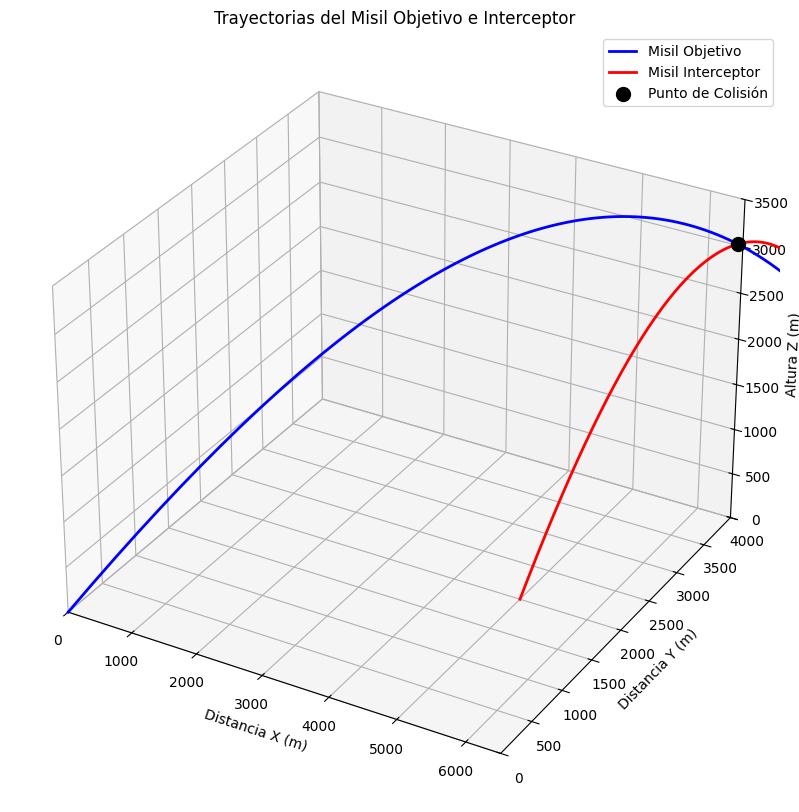

In [99]:
#e- AHORA GRAFICAMOS LA TRAYECTORIA DE AMBOS MISILES USANDDO LOS PARAMETROS
#   OPTIMOS ENCONTRADOS ANTES
x2 = solucion_interceptor_opt.y[0]
y2 = solucion_interceptor_opt.y[1]
z2 = solucion_interceptor_opt.y[2]
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x1,y1,z1,label='Misil Objetivo',color='blue',linewidth=2)
ax.plot(x2,y2,z2,label='Misil Interceptor',color='red',linewidth=2)
ax.scatter(x_colision, y_colision, z_colision, color='black', s=100, label='Punto de Colisión')

ax.set_xlim(0, 6500)
ax.set_ylim(0,4000)
ax.set_zlim(0,3500)
ax.set_xlabel('Distancia X (m)')
ax.set_ylabel('Distancia Y (m)')
ax.set_zlabel('Altura Z (m)')
ax.set_title('Trayectorias del Misil Objetivo e Interceptor')
ax.legend()
plt.show()


In [ ]:
#f- USAMOS LA FUNCION DE ANIMACION DE MATPLOTLIB PARA CREAR UNA ANIMACION DE LAS TRAYECTORIAS DE LOS MISISLES ESTA PARTE 
# LA HICE CASI EN SU TOTALIDAD CON IA YA QUE NUNCA HABIA TRABAJADO CON ANNIMACIONES EN PYTHON
%matplotlib inline

t_total = np.linspace(0,tiempo_choque,500)

simulacion_objetivo.sol(t_total)
x_1_ani = simulacion_objetivo.sol(t_total)[0]
y_1_ani = simulacion_objetivo.sol(t_total)[1]
z_1_ani = simulacion_objetivo.sol(t_total)[2]

x_2_ani = np.zeros_like(t_total)
y_2_ani = np.zeros_like(t_total)
z_2_ani = np.zeros_like(t_total)

# Separamos el tiempo en dos etapas
t_espera_2 = t_total < retardo
t_vuelo_2 = t_total >= retardo

# Etapa A: Mientras el tiempo sea menor al retardo, está en la base
x_2_ani[t_espera_2] = 5000.0  # Su posición X inicial
y_2_ani[t_espera_2] = 2000.0  # Su posición Y inicial
z_2_ani[t_espera_2] = 0.0     # Su posición Z inicial

# Etapa B: Cuando el tiempo supera el retardo, le pedimos la posición real al solver
posiciones_vuelo = solucion_interceptor_opt.sol(t_total[t_vuelo_2])

x_2_ani[t_vuelo_2] = posiciones_vuelo[0]
y_2_ani[t_vuelo_2] = posiciones_vuelo[1]
z_2_ani[t_vuelo_2] = posiciones_vuelo[2]
#CONFIGURAMOS LA ANIMACION

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim([0, max(np.max(x_1_ani), np.max(x_2_ani))])
ax.set_ylim([0, max(np.max(y_1_ani), np.max(y_2_ani))])
ax.set_zlim([0, max(np.max(z_1_ani), np.max(z_2_ani))])

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Animación de Intercepción de Misiles')

# Misil 1 (Objetivo) - Azul
linea1, = ax.plot([], [], [], 'b-', lw=1.5, alpha=0.6)
punto1, = ax.plot([], [], [], 'bo', markersize=6, label='Objetivo')

# Misil 2 (Interceptor) - Rojo
linea2, = ax.plot([], [], [], 'r-', lw=1.5, alpha=0.6)
punto2, = ax.plot([], [], [], 'ro', markersize=6, label='Interceptor')

explosion, = ax.plot([], [], [], 'y*', markersize=15)

ax.legend()

def init():
    linea1.set_data_3d([], [], [])
    punto1.set_data_3d([], [], [])
    linea2.set_data_3d([], [], [])
    punto2.set_data_3d([], [], [])
    explosion.set_data_3d([], [], [])
    return linea1, punto1, linea2, punto2, explosion

def update(frame):
    
    linea1.set_data_3d(x_1_ani[:frame+1], y_1_ani[:frame+1], z_1_ani[:frame+1])
    linea2.set_data_3d(x_2_ani[:frame+1], y_2_ani[:frame+1], z_2_ani[:frame+1])
    punto1.set_data_3d([x_1_ani[frame]], [y_1_ani[frame]], [z_1_ani[frame]])
    punto2.set_data_3d([x_2_ani[frame]], [y_2_ani[frame]], [z_2_ani[frame]])
    if frame == len(t_total) - 1:
        explosion.set_data_3d([x_2_ani[frame]], [y_2_ani[frame]], [z_2_ani[frame]])
        ani.event_source.stop()  # Detenemos la animación después de mostrar la explosión

    return linea1, punto1, linea2, punto2, explosion

ani = FuncAnimation(fig, update, frames=len(t_total), interval=100, blit=False)

from IPython.display import HTML, display

# 1. EVITAMOS que Jupyter imprima el gráfico estático vacío por duplicado
plt.close() 

# 2. GENERAMOS el reproductor de video HTML y forzamos su visualización
reproductor = HTML(ani.to_jshtml())
display(reproductor)
ani.save('animacion_colision.gif', writer='pillow', fps=15)
print("Animación guardada como 'animacion_colision.gif'")



Animation size has reached 21027237 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.
